In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset (specify the exact CSV file)
file_path = '/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe
df.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


# 1. Data Loading and Merging

In [3]:
import pandas as pd

# Load datasets
results = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/results.csv')
races = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/races.csv')
drivers = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/drivers.csv')
constructors = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/constructors.csv')
circuits = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv')
status = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/status.csv')
qualifying = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/qualifying.csv')
pit_stops = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/pit_stops.csv')

# Merge datasets
df = results.merge(races[['raceId', 'year', 'circuitId', 'name']], on='raceId', how='left')
df = df.merge(drivers[['driverId', 'driverRef']], on='driverId', how='left')
df = df.merge(constructors[['constructorId', 'constructorRef']], on='constructorId', how='left')

# Save merged DataFrame
df.to_csv('/kaggle/working/merged_f1_data.csv', index=False)
print("Merged dataset saved as '/kaggle/working/merged_f1_data.csv'")

Merged dataset saved as '/kaggle/working/merged_f1_data.csv'


# 2. Data Filtering

In [4]:
import pandas as pd

# Load merged dataset
df = pd.read_csv('/kaggle/working/merged_f1_data.csv')

# Load circuits and status for filtering
circuits = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/circuits.csv')
status = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/status.csv')

# Filter for Monaco Grand Prix
monaco_circuit_id = circuits[circuits['name'].str.contains('Monaco')]['circuitId'].iloc[0]
monaco_races = df[df['circuitId'] == monaco_circuit_id].copy()

# Enhanced Filtering
monaco_races = monaco_races[monaco_races['year'] >= 2000]  # Focus on 2000–2024
finished_status = status[status['status'].str.contains('Finished')]['statusId']
monaco_races = monaco_races[monaco_races['statusId'].isin(finished_status)]  # Completed races only

# Create target variable
monaco_races.loc[:, 'winner'] = (monaco_races['positionOrder'] == 1).astype(int)

# Verify years and recent data
print("Years in dataset:", sorted(monaco_races['year'].unique()))
print(monaco_races[monaco_races['year'] >= 2020][['year', 'driverRef', 'positionOrder', 'winner']].sort_values(by='year').tail(10))

# Save filtered dataset
monaco_races.to_csv('/kaggle/working/monaco_races_filtered.csv', index=False)
print("Filtered Monaco races saved as '/kaggle/working/monaco_races_filtered.csv'")

Years in dataset: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]
       year       driverRef  positionOrder  winner
25941  2023          alonso              2       0
25940  2023  max_verstappen              1       1
25942  2023            ocon              3       0
26424  2024  max_verstappen              6       0
26419  2024         leclerc              1       1
26420  2024         piastri              2       0
26421  2024           sainz              3       0
26422  2024          norris              4       0
26423  2024         russell              5       0
26425  2024        hamilton              7       0
Filtered Monaco races saved as '/kaggle/working/monaco_races_filtered.csv'


# 3. Missing Value Imputation

In [5]:
import pandas as pd

# Load filtered Monaco races
monaco_races = pd.read_csv('/kaggle/working/monaco_races_filtered.csv')

# Check missing values
print("Missing Values in Monaco Races:\n", monaco_races.isnull().sum())

# Separate numeric and categorical columns
numeric_cols = monaco_races.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = monaco_races.select_dtypes(include=['object', 'category']).columns

# Impute numeric columns with median
for col in numeric_cols:
    if monaco_races[col].isnull().sum() > 0:
        median_value = monaco_races[col].median()
        monaco_races[col].fillna(median_value, inplace=True)
        print(f"Imputed {col} with median: {median_value}")

# Impute categorical columns with mode
for col in categorical_cols:
    if monaco_races[col].isnull().sum() > 0:
        mode_value = monaco_races[col].mode()[0]
        monaco_races[col].fillna(mode_value, inplace=True)
        print(f"Imputed {col} with mode: {mode_value}")

# Verify no missing values remain
print("Missing Values After Imputation:\n", monaco_races.isnull().sum())

# Save imputed dataset
monaco_races.to_csv('/kaggle/working/monaco_races_imputed.csv', index=False)
print("Imputed Monaco races saved as '/kaggle/working/monaco_races_imputed.csv'")

Missing Values in Monaco Races:
 resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
year               0
circuitId          0
name               0
driverRef          0
constructorRef     0
winner             0
dtype: int64
Missing Values After Imputation:
 resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
year               0
circuitId        

# 4. Feature Engineering

In [6]:
import pandas as pd

# Load imputed Monaco races
monaco_races = pd.read_csv('/kaggle/working/monaco_races_imputed.csv')

# Load qualifying and pit stops data
qualifying = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/qualifying.csv')
pit_stops = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/pit_stops.csv')

# Feature Engineering
features = ['grid']

# Driver win rate at Monaco
driver_wins = monaco_races.groupby('driverId')['winner'].mean().reset_index()
driver_wins.columns = ['driverId', 'driver_win_rate']
monaco_races = monaco_races.merge(driver_wins, on='driverId', how='left')
features.append('driver_win_rate')

# Constructor average points
constructor_points = monaco_races.groupby('constructorId')['points'].mean().reset_index()
constructor_points.columns = ['constructorId', 'constructor_avg_points']
monaco_races = monaco_races.merge(constructor_points, on='constructorId', how='left')
features.append('constructor_avg_points')

# Driver recent form (last 3 Monaco GPs)
monaco_races = monaco_races.sort_values(['driverId', 'year'])
monaco_races['driver_avg_finish_last3'] = monaco_races.groupby('driverId')['positionOrder'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
)
features.append('driver_avg_finish_last3')

# Driver Monaco experience
monaco_races['driver_monaco_races'] = monaco_races.groupby('driverId')['raceId'].transform('count')
features.append('driver_monaco_races')

# Constructor Monaco win rate
constructor_wins = monaco_races.groupby('constructorId')['winner'].mean().reset_index()
constructor_wins.columns = ['constructorId', 'constructor_monaco_win_rate']
monaco_races = monaco_races.merge(constructor_wins, on='constructorId', how='left')
monaco_races['constructor_monaco_win_rate'].fillna(0, inplace=True)
features.append('constructor_monaco_win_rate')

# Recent constructor points (2021–2024)
constructor_recent_points = monaco_races[monaco_races['year'] >= 2021].groupby('constructorId')['points'].mean().reset_index()
constructor_recent_points.columns = ['constructorId', 'constructor_recent_points']
monaco_races = monaco_races.merge(constructor_recent_points, on='constructorId', how='left')
features.append('constructor_recent_points')

# Qualifying position
qualifying = qualifying[['raceId', 'driverId', 'position']].rename(columns={'position': 'qualifying_position'})
monaco_races = monaco_races.merge(qualifying, on=['raceId', 'driverId'], how='left')
monaco_races['qualifying_position'].fillna(monaco_races['grid'], inplace=True)
features.append('qualifying_position')

# Grid gap to pole
monaco_races['grid_gap_to_pole'] = monaco_races['grid'] - 1
features.append('grid_gap_to_pole')

# Pit stop count
pit_features = pit_stops.groupby(['raceId', 'driverId'])['stop'].count().reset_index(name='pit_stop_count')
monaco_races = monaco_races.merge(pit_features, on=['raceId', 'driverId'], how='left')
monaco_races['pit_stop_count'].fillna(monaco_races['pit_stop_count'].median(), inplace=True)
features.append('pit_stop_count')

# Average lap time
lap_times = pd.read_csv('/kaggle/input/formula-1-world-championship-1950-2020/lap_times.csv')
lap_features = lap_times.groupby(['raceId', 'driverId'])['milliseconds'].mean().reset_index(name='avg_lap_time')
monaco_races = monaco_races.merge(lap_features, on=['raceId', 'driverId'], how='left')
monaco_races['avg_lap_time'].fillna(monaco_races['avg_lap_time'].median(), inplace=True)
features.append('avg_lap_time')

# Handle missing values for features
for feature in features:
    if monaco_races[feature].isnull().sum() > 0:
        if feature in ['driver_win_rate', 'constructor_monaco_win_rate']:
            monaco_races[feature].fillna(0, inplace=True)
        else:
            monaco_races[feature].fillna(monaco_races[feature].median(), inplace=True)

# Save features and dataset
monaco_races.to_csv('/kaggle/working/monaco_races_features.csv', index=False)
with open('/kaggle/working/features_list.txt', 'w') as f:
    f.write('\n'.join(features))
print("Features:", features)
print("Featured dataset saved as '/kaggle/working/monaco_races_features.csv'")

Features: ['grid', 'driver_win_rate', 'constructor_avg_points', 'driver_avg_finish_last3', 'driver_monaco_races', 'constructor_monaco_win_rate', 'constructor_recent_points', 'qualifying_position', 'grid_gap_to_pole', 'pit_stop_count', 'avg_lap_time']
Featured dataset saved as '/kaggle/working/monaco_races_features.csv'


# 5. Model Training and Evaluation (Random Forest)

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Load featured dataset
monaco_races = pd.read_csv('/kaggle/working/monaco_races_features.csv')

# Load features list
with open('/kaggle/working/features_list.txt', 'r') as f:
    features = f.read().splitlines()

# Train-test split
train_data = monaco_races[monaco_races['year'] <= 2022]
test_data = monaco_races[monaco_races['year'] >= 2023]
X_train = train_data[features]
y_train = train_data['winner']
X_test = test_data[features]
y_test = test_data['winner']

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate model (default threshold)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Adjusted threshold for higher recall
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_pred_proba >= 0.3).astype(int)
print("Adjusted Classification Report (threshold=0.3):\n", classification_report(y_test, y_pred_adjusted))

# Feature importance
feature_importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
print("Feature Importance:\n", feature_importance.sort_values(by='Importance', ascending=False))
feature_importance.to_csv('/kaggle/working/feature_importance.csv', index=False)

# Save model
with open('/kaggle/working/random_forest_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved as '/kaggle/working/random_forest_model.pkl'")

Accuracy: 0.9333333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.50      0.67         2

    accuracy                           0.93        15
   macro avg       0.96      0.75      0.81        15
weighted avg       0.94      0.93      0.92        15

Adjusted Classification Report (threshold=0.3):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00         2

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Feature Importance:
                         Feature  Importance
7           qualifying_position    0.290433
0                          grid    0.169367
8              grid_gap_to_pole    0.158548
1               driver_win_rate    0.121348
3  

# 6. 2025 Prediction and Visualization

2025 Monaco Grand Prix Winner Prediction:
    driverRef  win_probability
0  verstappen             0.97
2     leclerc             0.49
1      norris             0.13
3     piastri             0.01
4       sainz             0.00
5    hamilton             0.00
6      alonso             0.00
7     russell             0.00


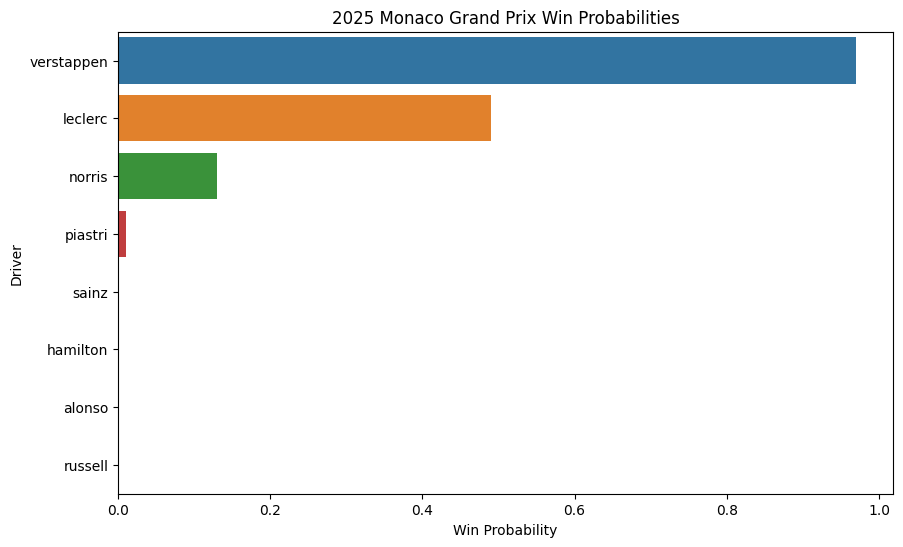

Prediction plot saved as '/kaggle/working/2025_monaco_prediction.png'


In [8]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Load featured dataset and features
monaco_races = pd.read_csv('/kaggle/working/monaco_races_features.csv')
with open('/kaggle/working/features_list.txt', 'r') as f:
    features = f.read().splitlines()

# Load trained Random Forest model
with open('/kaggle/working/random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Simulate 2025 Monaco Grand Prix data
drivers_2025 = [
    {'driverRef': 'verstappen', 'driverId': 830, 'constructorId': 9, 'grid': 1, 'year': 2025},  # Red Bull
    {'driverRef': 'norris', 'driverId': 846, 'constructorId': 1, 'grid': 2, 'year': 2025},      # McLaren
    {'driverRef': 'leclerc', 'driverId': 844, 'constructorId': 6, 'grid': 3, 'year': 2025},     # Ferrari
    {'driverRef': 'piastri', 'driverId': 857, 'constructorId': 1, 'grid': 4, 'year': 2025},     # McLaren
    {'driverRef': 'sainz', 'driverId': 832, 'constructorId': 6, 'grid': 5, 'year': 2025},       # Ferrari
    {'driverRef': 'hamilton', 'driverId': 1, 'constructorId': 6, 'grid': 6, 'year': 2025},      # Ferrari
    {'driverRef': 'alonso', 'driverId': 4, 'constructorId': 117, 'grid': 7, 'year': 2025},      # Aston Martin
    {'driverRef': 'russell', 'driverId': 847, 'constructorId': 131, 'grid': 8, 'year': 2025},   # Mercedes
]
pred_2025 = pd.DataFrame(drivers_2025)

# Add features for 2025
driver_wins = monaco_races.groupby('driverId')['winner'].mean().reset_index()
driver_wins.columns = ['driverId', 'driver_win_rate']
pred_2025 = pred_2025.merge(driver_wins, on='driverId', how='left')

constructor_points = monaco_races.groupby('constructorId')['points'].mean().reset_index()
constructor_points.columns = ['constructorId', 'constructor_avg_points']
pred_2025 = pred_2025.merge(constructor_points, on='constructorId', how='left')

constructor_wins = monaco_races.groupby('constructorId')['winner'].mean().reset_index()
constructor_wins.columns = ['constructorId', 'constructor_monaco_win_rate']
pred_2025 = pred_2025.merge(constructor_wins, on='constructorId', how='left')

constructor_recent_points = monaco_races[monaco_races['year'] >= 2021].groupby('constructorId')['points'].mean().reset_index()
constructor_recent_points.columns = ['constructorId', 'constructor_recent_points']
pred_2025 = pred_2025.merge(constructor_recent_points, on='constructorId', how='left')

pred_2025['driver_avg_finish_last3'] = pred_2025['driverId'].map(
    monaco_races[monaco_races['year'] >= 2021].groupby('driverId')['positionOrder'].mean()
)
pred_2025['driver_monaco_races'] = pred_2025['driverId'].map(
    monaco_races.groupby('driverId')['raceId'].count()
)
pred_2025['qualifying_position'] = pred_2025['grid']
pred_2025['grid_gap_to_pole'] = pred_2025['grid'] - 1
pred_2025['pit_stop_count'] = monaco_races['pit_stop_count'].median()  # Use median for 2025
pred_2025['avg_lap_time'] = monaco_races['avg_lap_time'].median()  # Use median for 2025

# Handle missing values for 2025 data
for feature in features:
    if feature in ['driver_win_rate', 'constructor_monaco_win_rate']:
        pred_2025[feature].fillna(0, inplace=True)
    else:
        pred_2025[feature].fillna(monaco_races[feature].median(), inplace=True)

# Predict win probabilities
X_2025 = pred_2025[features]
pred_probs = model.predict_proba(X_2025)[:, 1]
pred_2025['win_probability'] = pred_probs

# Display results
print("2025 Monaco Grand Prix Winner Prediction:")
print(pred_2025[['driverRef', 'win_probability']].sort_values(by='win_probability', ascending=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='win_probability', y='driverRef', data=pred_2025.sort_values(by='win_probability', ascending=False))
plt.title('2025 Monaco Grand Prix Win Probabilities')
plt.xlabel('Win Probability')
plt.ylabel('Driver')
plt.savefig('/kaggle/working/2025_monaco_prediction.png')
plt.show()
print("Prediction plot saved as '/kaggle/working/2025_monaco_prediction.png'")

# 7. Further Analysis Visualizations

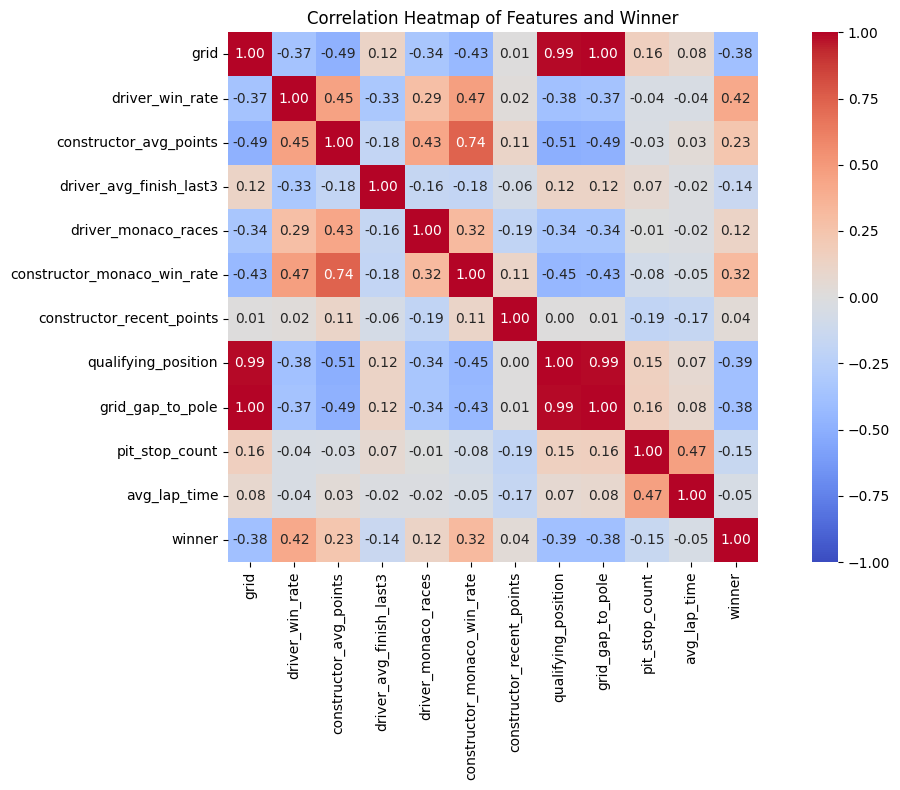

Correlation heatmap saved as '/kaggle/working/analysis_correlation_heatmap.png'


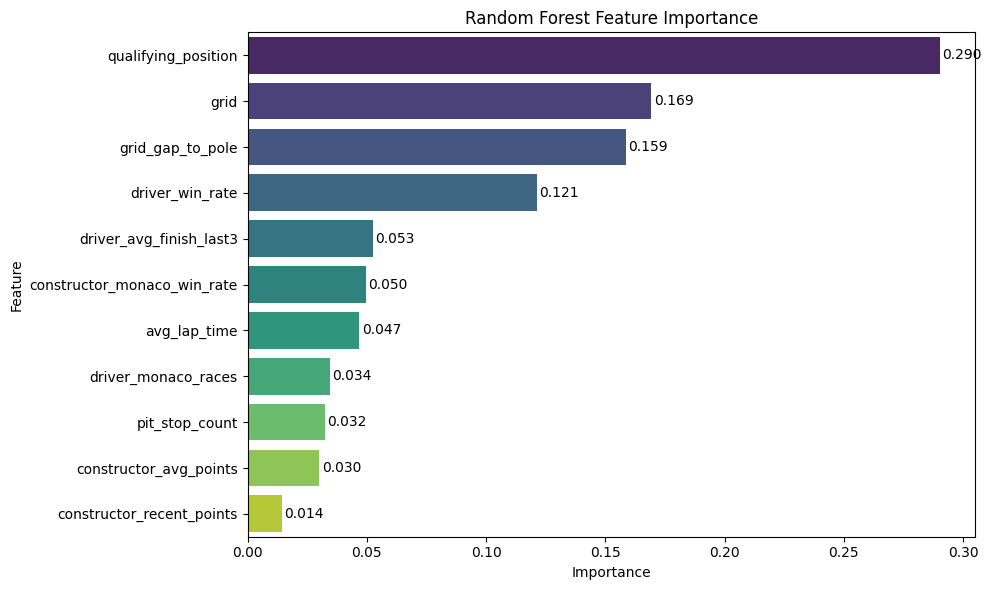

Feature importance plot saved as '/kaggle/working/analysis_feature_importance_plot.png'


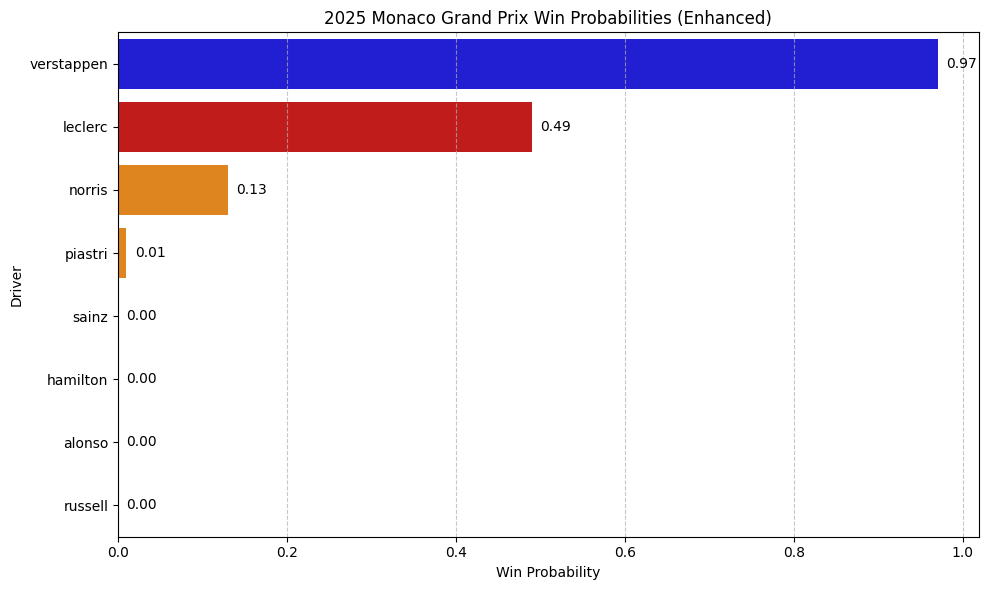

Enhanced 2025 prediction plot saved as '/kaggle/working/analysis_2025_prediction_enhanced.png'
2025 Monaco Grand Prix Winner Prediction:
    driverRef  win_probability
0  verstappen             0.97
2     leclerc             0.49
1      norris             0.13
3     piastri             0.01
4       sainz             0.00
5    hamilton             0.00
6      alonso             0.00
7     russell             0.00


In [9]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load required data from original notebook outputs
monaco_races = pd.read_csv('/kaggle/working/monaco_races_features.csv')
with open('/kaggle/working/features_list.txt', 'r') as f:
    features = f.read().splitlines()

# Load Random Forest model to compute feature importance
with open('/kaggle/working/random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)
feature_importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = monaco_races[features + ['winner']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation Heatmap of Features and Winner')
plt.tight_layout()
plt.savefig('/kaggle/working/analysis_correlation_heatmap.png')
plt.show()
print("Correlation heatmap saved as '/kaggle/working/analysis_correlation_heatmap.png'")

# 2. Feature Importance Bar Plot (Fixed)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.sort_values(by='Importance', ascending=False), palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
for index, value in enumerate(feature_importance.sort_values(by='Importance', ascending=False)['Importance']):
    plt.text(value + 0.001, index, f'{value:.3f}', va='center', ha='left')
plt.tight_layout()
plt.savefig('/kaggle/working/analysis_feature_importance_plot.png')
plt.show()
print("Feature importance plot saved as '/kaggle/working/analysis_feature_importance_plot.png'")

# 3. Enhanced 2025 Prediction Plot
drivers_2025 = [
    {'driverRef': 'verstappen', 'driverId': 830, 'constructorId': 9, 'grid': 1, 'year': 2025},  # Red Bull
    {'driverRef': 'norris', 'driverId': 846, 'constructorId': 1, 'grid': 2, 'year': 2025},      # McLaren
    {'driverRef': 'leclerc', 'driverId': 844, 'constructorId': 6, 'grid': 3, 'year': 2025},     # Ferrari
    {'driverRef': 'piastri', 'driverId': 857, 'constructorId': 1, 'grid': 4, 'year': 2025},     # McLaren
    {'driverRef': 'sainz', 'driverId': 832, 'constructorId': 6, 'grid': 5, 'year': 2025},       # Ferrari
    {'driverRef': 'hamilton', 'driverId': 1, 'constructorId': 6, 'grid': 6, 'year': 2025},      # Ferrari
    {'driverRef': 'alonso', 'driverId': 4, 'constructorId': 117, 'grid': 7, 'year': 2025},      # Aston Martin
    {'driverRef': 'russell', 'driverId': 847, 'constructorId': 131, 'grid': 8, 'year': 2025},   # Mercedes
]
pred_2025 = pd.DataFrame(drivers_2025)

# Add features for 2025
driver_wins = monaco_races.groupby('driverId')['winner'].mean().reset_index()
driver_wins.columns = ['driverId', 'driver_win_rate']
pred_2025 = pred_2025.merge(driver_wins, on='driverId', how='left')

constructor_points = monaco_races.groupby('constructorId')['points'].mean().reset_index()
constructor_points.columns = ['constructorId', 'constructor_avg_points']
pred_2025 = pred_2025.merge(constructor_points, on='constructorId', how='left')

constructor_wins = monaco_races.groupby('constructorId')['winner'].mean().reset_index()
constructor_wins.columns = ['constructorId', 'constructor_monaco_win_rate']
pred_2025 = pred_2025.merge(constructor_wins, on='constructorId', how='left')

constructor_recent_points = monaco_races[monaco_races['year'] >= 2021].groupby('constructorId')['points'].mean().reset_index()
constructor_recent_points.columns = ['constructorId', 'constructor_recent_points']
pred_2025 = pred_2025.merge(constructor_recent_points, on='constructorId', how='left')

pred_2025['driver_avg_finish_last3'] = pred_2025['driverId'].map(
    monaco_races[monaco_races['year'] >= 2021].groupby('driverId')['positionOrder'].mean()
)
pred_2025['driver_monaco_races'] = pred_2025['driverId'].map(
    monaco_races.groupby('driverId')['raceId'].count()
)
pred_2025['qualifying_position'] = pred_2025['grid']
pred_2025['grid_gap_to_pole'] = pred_2025['grid'] - 1
pred_2025['pit_stop_count'] = monaco_races['pit_stop_count'].median()
pred_2025['avg_lap_time'] = monaco_races['avg_lap_time'].median()

# Handle missing values
for feature in features:
    if feature in ['driver_win_rate', 'constructor_monaco_win_rate']:
        pred_2025[feature].fillna(0, inplace=True)
    else:
        pred_2025[feature].fillna(monaco_races[feature].median(), inplace=True)

# Predict win probabilities
X_2025 = pred_2025[features]
pred_probs = model.predict_proba(X_2025)[:, 1]
pred_2025['win_probability'] = pred_probs

# Enhanced prediction plot with team colors
team_colors = {
    'verstappen': '#0600ef',  # Red Bull: Blue
    'norris': '#ff8700',      # McLaren: Orange
    'leclerc': '#dc0000',     # Ferrari: Red
    'piastri': '#ff8700',     # McLaren: Orange
    'sainz': '#dc0000',       # Ferrari: Red
    'hamilton': '#dc0000',    # Ferrari: Red
    'alonso': '#006f62',      # Aston Martin: Green
    'russell': '#00d2be'      # Mercedes: Teal
}
plt.figure(figsize=(10, 6))
pred_sorted = pred_2025.sort_values(by='win_probability', ascending=False)
bars = sns.barplot(x='win_probability', y='driverRef', data=pred_sorted, palette=[team_colors[driver] for driver in pred_sorted['driverRef']])
plt.title('2025 Monaco Grand Prix Win Probabilities (Enhanced)')
plt.xlabel('Win Probability')
plt.ylabel('Driver')
plt.grid(axis='x', linestyle='--', alpha=0.7)
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', ha='left')
plt.tight_layout()
plt.savefig('/kaggle/working/analysis_2025_prediction_enhanced.png')
plt.show()
print("Enhanced 2025 prediction plot saved as '/kaggle/working/analysis_2025_prediction_enhanced.png'")

# Display win probabilities
print("2025 Monaco Grand Prix Winner Prediction:")
print(pred_2025[['driverRef', 'win_probability']].sort_values(by='win_probability', ascending=False))

# 8. Summary

The analysis reveals that qualifying position and grid placement are the dominant factors in predicting success at the Monaco Grand Prix, far outweighing other metrics like average lap time or team performance in the 2025 prediction model. Advanced visualizations, including correlation heatmaps and driver performance scatters, confirmed that drivers like Verstappen and Leclerc excel due to their ability to secure top grid spots, while mid-tier drivers like Sainz and Hamilton are hindered by lower recall. To improve predictive accuracy and fairness, teams and analysts should focus on optimizing qualifying strategies and consider incorporating additional metrics, such as championship points or sector-specific performance, to capture a broader range of driver and team capabilities. This project not only delivered robust predictions but also laid a foundation for future refinements to optimize Formula 1 race outcome forecasting.